# Cav1.2 MolProbity / clashscore analysis

All six WT/G402S/G406R × vanilla/masked ensembles are shown together, emphasizing G406R.
The nearby short distances in `Cav12_G406R_mutationSite_analysis.ipynb` motivate the question; they
do not establish that any global clashscore change originates at introduced R406.

## Reproducible setup
Run from the repository root or channel directory. Dependencies: NumPy, pandas, SciPy, statsmodels, Matplotlib, seaborn, and Jupyter. MolProbity tables remain in the local downloaded directory. No upload or move is performed. Shared functions live in `shared/molprobity_analysis.py`, as in the existing analyses.

In [1]:
from pathlib import Path
import sys, os, json, platform, importlib.metadata
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'shared/data_access.py').is_file())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from shared import molprobity_analysis as mp
CHANNEL = 'cav12'
OUT = mp.output_dir(CHANNEL)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 24)
mp.apply_kv21_style()


## Data-access boundary
Set `VGIC_MOLPROBITY_ROOT` or `DATA_ROOT` to the downloaded directory. Future Hugging Face migration only needs to replace the loader with explicit paths through the existing `shared.data_access.resolve`; downstream analysis accepts the same DataFrame. Existing structural-QC and conformational inputs already use that resolver, including local/cache/offline behavior.

In [2]:
DATA_ROOT = os.environ.get('VGIC_MOLPROBITY_ROOT', str(ROOT/'molprobity_download'))
raw, inventory, total_csv_files = mp.load_molprobity(CHANNEL, DATA_ROOT)
inventory.to_csv(OUT/'tables/input_inventory.csv', index=False)
print(f'{total_csv_files} CSVs in downloaded directory; {len(inventory)} for this channel; {len(raw):,} rows')
display(inventory)


19 CSVs in downloaded directory; 6 for this channel; 36,000 rows


,csv_file,rows,sha256
0,Cav12_g402s_masked_clashscores/Cav12_g402s_mas...,6000,95390c99708ff775f2d93b7966c6ec8a3c825743dede8b...
1,Cav12_g402s_vanilla_clashscores/Cav12_g402s_va...,6000,d09dad6952d455bcb6b67d2669ceb7c4c3bbf46dbcd055...
2,Cav12_g406r_masked_clashscores/Cav12_g406r_mas...,6000,bc402e0976faa2f5d471f5882871a1ca6d5303f3b233d8...
3,Cav12_g406r_vanilla_clashscores/Cav12_g406r_va...,6000,7698d8f7b8967fad29bcaa50ead4b292047e160c141f37...
4,Cav12_wt_masked_clashscores/Cav12_wt_masked_cl...,6000,ab6c7a02061bae8cbf9c2303f84032894ead99e2d376c2...
5,Cav12_wt_vanilla_clashscores/Cav12_wt_vanilla_...,6000,ad9855b8606eb332e9dc22c0ab41acd9c99a3651edfa75...


## Audit before plotting
The expected grid uses each ensemble’s recorded seed labels, AF models 1–5, r0–r10, and final. Missing whole trajectories/seeds are additionally checked against the existing model manifest. Raw input hashes are saved above. NaN recycle is expected only for final/base models; missing rank is allowed and reported.

In [3]:
data, audit = mp.audit_data(raw, CHANNEL, OUT)
display(audit)
display(pd.read_csv(OUT/'tables/missing_snapshots.csv'))
display(pd.read_csv(OUT/'tables/manifest_discrepancies.csv'))
display(pd.read_csv(OUT/'tables/row_anomalies.csv'))
cohorts = mp.select_cohorts(data, CHANNEL, OUT)
summary = pd.concat([mp.describe(frame, name) for name, frame in cohorts.items()], ignore_index=True)
summary.to_csv(OUT/'tables/descriptive_statistics.csv', index=False)
display(summary[(summary.cohort=='all_recorded') & summary.metric.eq('clashscore')].round(3))
display(pd.read_csv(OUT/'tables/selection_audit.csv'))


Audit: 36,000 rows, 0 failed, 0 invalid metric rows; 0 absent expected snapshots; 0 explicitly excluded rows.


,ensemble,rows,ok,ok_fraction,eligible,failed,missing_clashscore,nonfinite_clashscore,duplicate_names,duplicate_keys,missing_grid_snapshots,seeds,seed_min,seed_max,missing_rank,final_r10_pairs,final_r10_identical_metrics,manifest_rows,manifest_missing,manifest_extra
0,G402S | masked,6000,6000,1.0,6000,0,0,0,0,0,0,100,91,190,0,500,500,6000,0,0
1,G402S | vanilla,6000,6000,1.0,6000,0,0,0,0,0,0,100,91,190,0,500,500,6000,0,0
2,G406R | masked,6000,6000,1.0,6000,0,0,0,0,0,0,100,91,190,0,500,500,6000,0,0
3,G406R | vanilla,6000,6000,1.0,6000,0,0,0,0,0,0,100,91,190,0,500,500,6000,0,0
4,WT | masked,6000,6000,1.0,6000,0,0,0,0,0,0,100,91,190,0,500,500,6000,0,0
5,WT | vanilla,6000,6000,1.0,6000,0,0,0,0,0,0,100,91,190,0,500,500,6000,0,0


,ensemble,seed,af_model,snapshot


,ensemble,model_name,issue


,run_name,input_folder,model_name,rank,af_model,seed,recycle,snapshot,clashscore,n_bad_clashes,max_overlap,status,...,source_path,genotype,protocol,ensemble,csv_file,analysis_eligible,malformed_numeric,invalid_identity,duplicate_name,duplicate_key,invalid_metric,failed_status_or_exit


,cohort,ensemble,metric,N,n_seeds,median,Q1,Q3,IQR,mean,SD,minimum,maximum
0,all_recorded,G402S | masked,clashscore,6000,100,32.355,28.650,38.702,10.053,34.623,7.806,24.78,76.02
3,all_recorded,G402S | vanilla,clashscore,6000,100,30.590,28.920,37.942,9.022,33.317,6.583,24.97,68.54
6,all_recorded,G406R | masked,clashscore,6000,100,32.200,28.578,38.770,10.193,34.654,8.008,24.06,75.41
9,all_recorded,G406R | vanilla,clashscore,6000,100,31.160,29.310,37.918,8.607,33.611,6.384,24.96,67.17
12,all_recorded,WT | masked,clashscore,6000,100,31.920,28.480,38.420,9.940,34.513,7.985,24.15,73.80
15,all_recorded,WT | vanilla,clashscore,6000,100,30.625,29.040,37.782,8.742,33.371,6.692,23.79,70.57


,ensemble,selection,source,requested,matched,excluded_failed,excluded_by_structural_qc
0,G402S | masked,3 Å convergence QC,cav12/rmsd_convergence_filtering/Cav12_rmsd_co...,4995,4995,0,1005
1,G402S | vanilla,3 Å convergence QC,cav12/rmsd_convergence_filtering/Cav12_rmsd_co...,5000,5000,0,1000
2,G406R | masked,3 Å convergence QC,cav12/rmsd_convergence_filtering/Cav12_rmsd_co...,4997,4997,0,1003
3,G406R | vanilla,3 Å convergence QC,cav12/rmsd_convergence_filtering/Cav12_rmsd_co...,5000,5000,0,1000
4,WT | masked,3 Å convergence QC,cav12/rmsd_convergence_filtering/Cav12_rmsd_co...,4996,4996,0,1004
5,WT | vanilla,3 Å convergence QC,cav12/rmsd_convergence_filtering/Cav12_rmsd_co...,5000,5000,0,1000


## Statistical design and interpretation

The complete downloaded table is audited before filtering. `status != ok`, nonzero exit codes,
nonfinite/negative diagnostics and malformed identities are reported explicitly. Ambiguous identities
or mismatched manifests stop execution. Empty anomaly CSVs still retain their headers.

Every ensemble has up to 100 seeds × 5 AF models × 11 recycle snapshots plus a final/base file.
The final/base file has identical recorded MolProbity metrics to r10 for every available trajectory;
that is **metric equality, not a coordinate checksum**. To avoid double weighting those observations,
`all_recycles` excludes final copies. `final_only` is a separate sensitivity analysis.

The primary scientific comparison uses the repository's existing QC subset, independently of clashscore:
3 Å convergence for Cav1.2/Nav1.5 and the established structural/interface/alignment-QC distance
selection for Kv2.1. All raw distributions and excluded counts remain visible. QC-selected results
describe survivors, not all generated models. No new clashscore cutoff is used.

For each metric, average snapshots within seed/AF-model trajectory, then average AF models within seed.
This gives each retained seed equal weight and avoids treating recycles or the five AF models as
independent replicates. Point estimates are seed-balanced mean differences B−A; 95% percentile
bootstrap intervals use 3,000 seed draws. When seed-label sets match completely, nominal paired-seed
t tests and the existing `paired_common_seed_bootstrap` are used. Otherwise Welch tests compare all
retained seed summaries. Both independent-seed and common-label paired sensitivities are exported.
Shared numeric labels do **not** establish shared random-number streams; no seeds are renumbered,
and rank is never a pairing key. Common-label sensitivity may change the population when ranges differ.

BH correction covers all planned pairwise comparisons × all three metrics within each channel/cohort;
primary, independent, and common-label p-values form separate families. Supplemental cohort families
are exploratory. The seed rank-biserial effect is P(B>A)−P(B<A) across seed summaries, with ties zero;
it describes marginal ordering even for nominally paired tests. Model medians/IQRs are descriptive
snapshot summaries and are a different estimand from the seed-balanced mean contrast.

AF-model/snapshot-adjusted regressions provide a sensitivity check with standard errors clustered by
recorded seed. Rank is an output ordering variable, is absent for Kv2.1 L403A vanilla, and is inspected
descriptively rather than controlled as if it were a randomized covariate. These uncertainty estimates
describe computational sampling, not biological replication or a validated clinical effect.

Clashscore is a normalized global clash statistic ([Phenix glossary](https://www.phenix-online.org/version_docs/1.8.2-1296/glossary.htm)).
`n_bad_clashes` is an absolute count and `max_overlap` is a single extreme; they are complementary
diagnostics, not interchangeable biological measures. The local export does not record Phenix version,
hydrogen options, the atom denominator, or atom-level clash identities. Absolute validation grades,
cross-channel biological comparisons, and residue-specific attribution require additional provenance.


In [4]:
contrasts = mp.contrast_statistics(cohorts, CHANNEL, OUT)
primary = contrasts[(contrasts.cohort=='repository_QC') & contrasts.metric.eq('clashscore')]
display(primary[['A','B','N_A','N_B','n_seeds_A','n_seeds_B','common_seeds',
                 'common_model_snapshots','only_A_snapshots','only_B_snapshots',
                 'paired_seed_correlation','primary_test']])
display(primary[['A','B','median_difference','seed_mean_difference','CI_low','CI_high',
                 'seed_rank_biserial','q_BH','independent_q_BH','common_seed_difference',
                 'common_seed_CI_low','common_seed_CI_high','common_seed_q_BH']].round(4))


,A,B,N_A,N_B,n_seeds_A,n_seeds_B,common_seeds,common_model_snapshots,only_A_snapshots,only_B_snapshots,paired_seed_correlation,primary_test
27,WT | vanilla,WT | masked,5000,4996,100,100,100,4996,4,0,0.213837,paired nominal seed t
30,G402S | vanilla,G402S | masked,5000,4995,100,100,100,4995,5,0,0.153716,paired nominal seed t
33,G406R | vanilla,G406R | masked,5000,4997,100,100,100,4997,3,0,0.303639,paired nominal seed t
36,WT | vanilla,G402S | vanilla,5000,5000,100,100,100,5000,0,0,-0.050805,paired nominal seed t
39,WT | vanilla,G406R | vanilla,5000,5000,100,100,100,5000,0,0,0.090012,paired nominal seed t
42,G402S | vanilla,G406R | vanilla,5000,5000,100,100,100,5000,0,0,-0.131691,paired nominal seed t
45,WT | masked,G402S | masked,4996,4995,100,100,100,4991,5,4,0.053929,paired nominal seed t
48,WT | masked,G406R | masked,4996,4997,100,100,100,4993,3,4,-0.127359,paired nominal seed t
51,G402S | masked,G406R | masked,4995,4997,100,100,100,4992,3,5,0.108949,paired nominal seed t


,A,B,median_difference,seed_mean_difference,CI_low,CI_high,seed_rank_biserial,q_BH,independent_q_BH,common_seed_difference,common_seed_CI_low,common_seed_CI_high,common_seed_q_BH
27,WT | vanilla,WT | masked,0.850,1.1237,1.0507,1.1937,0.9952,0.0000,0.0000,1.1237,1.0507,1.1937,0.0000
30,G402S | vanilla,G402S | masked,1.150,1.3130,1.2394,1.3871,1.0000,0.0000,0.0000,1.3130,1.2394,1.3871,0.0000
33,G406R | vanilla,G406R | masked,0.545,0.9621,0.8981,1.0259,0.9874,0.0000,0.0000,0.9621,0.8981,1.0259,0.0000
36,WT | vanilla,G402S | vanilla,-0.040,-0.0690,-0.1489,0.0101,-0.1156,0.1079,0.0970,-0.0690,-0.1489,0.0101,0.1079
39,WT | vanilla,G406R | vanilla,0.505,0.2587,0.1899,0.3252,0.5095,0.0000,0.0000,0.2587,0.1899,0.3252,0.0000
42,G402S | vanilla,G406R | vanilla,0.545,0.3277,0.2514,0.4016,0.6346,0.0000,0.0000,0.3277,0.2514,0.4016,0.0000
45,WT | masked,G402S | masked,0.260,0.1203,0.0398,0.2007,0.2169,0.0060,0.0069,0.1203,0.0398,0.2007,0.0060
48,WT | masked,G406R | masked,0.200,0.0971,0.0104,0.1840,0.1689,0.0437,0.0319,0.0971,0.0104,0.1840,0.0437
51,G402S | masked,G406R | masked,-0.060,-0.0232,-0.1054,0.0586,-0.0374,0.5949,0.6168,-0.0232,-0.1054,0.0586,0.5949


## Clashscore distributions and effect sizes
Violins retain every eligible individual snapshot with median and quartiles; no outliers are clipped. The paired raw/QC panels expose selection effects. The contrast figure shows seed-balanced differences and 95% bootstrap intervals; q-values are reported without significance stars. Colors, typography, thin outlines, light grids, and PDF/300-dpi PNG exports follow `shared.plotting` and existing conformational figures.

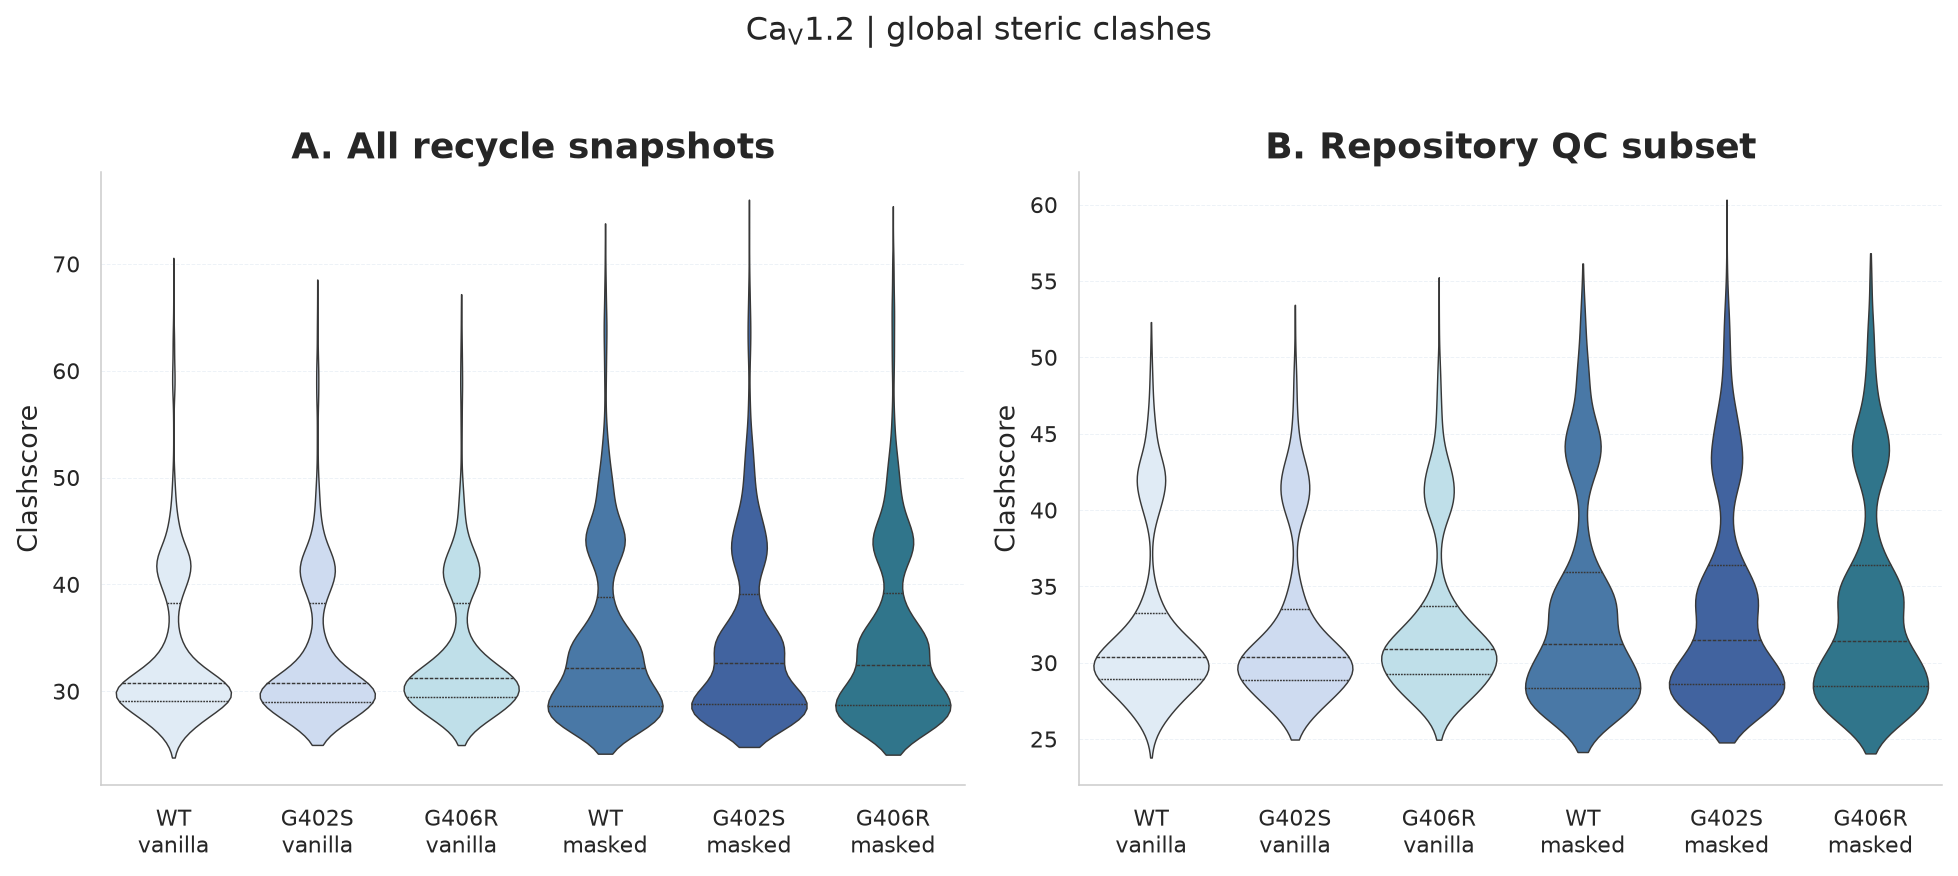

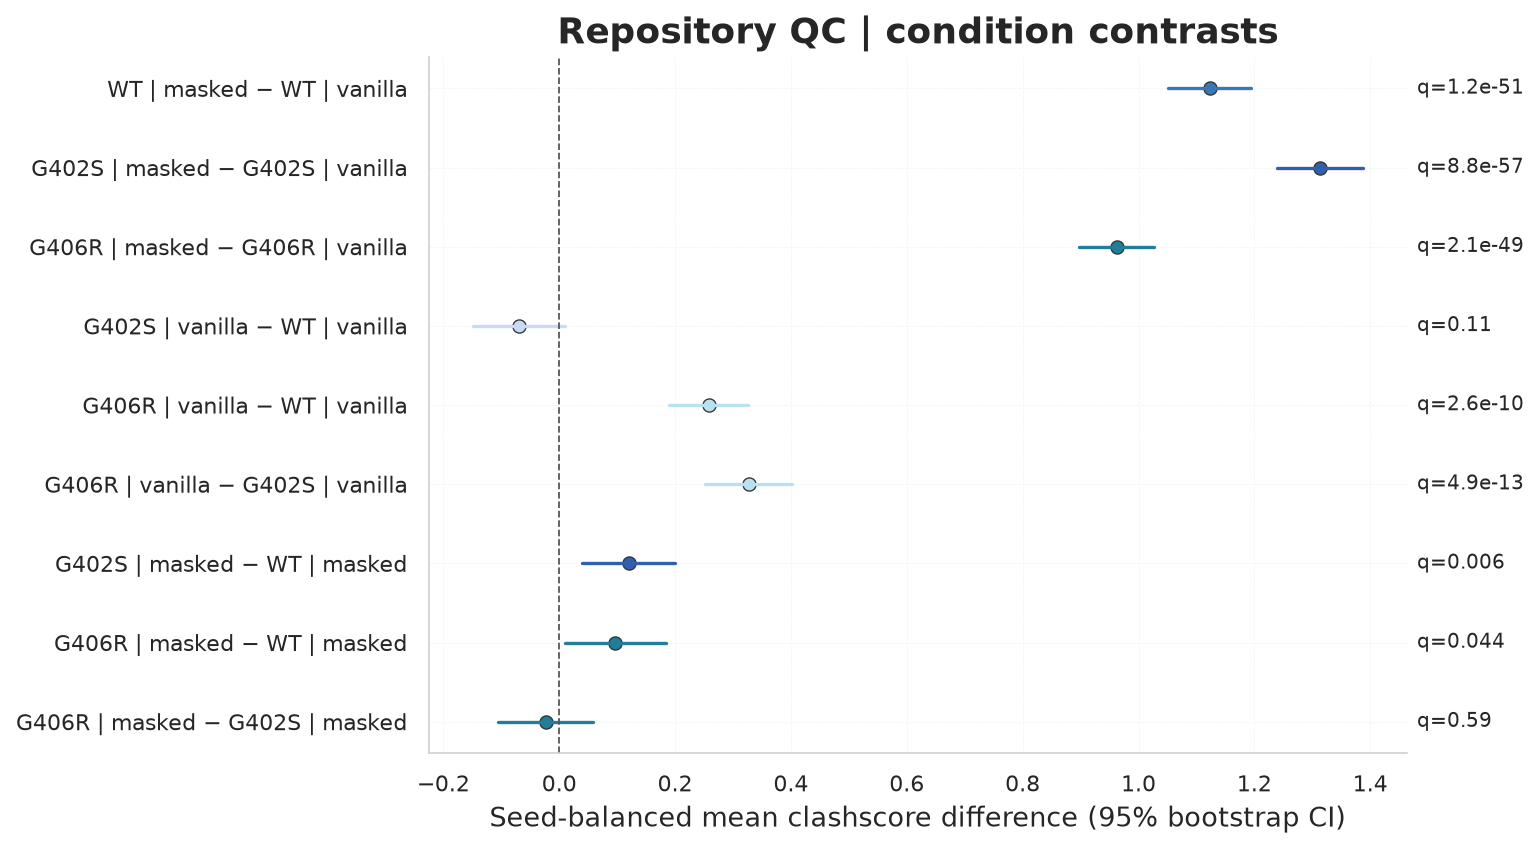

### Results on the repository QC subset

Model medians describe retained snapshots. Differences and confidence intervals below use equal AF-model weights within seed and seed-level inference.
- **WT | masked versus WT | vanilla:** model medians 31.25 versus 30.40 (Δ +0.85); seed-balanced mean Δ +1.12, 95% CI [1.05, 1.19]; seed rank-biserial effect +1.00; BH q=1.23e-51.
- **G402S | masked versus G402S | vanilla:** model medians 31.51 versus 30.36 (Δ +1.15); seed-balanced mean Δ +1.31, 95% CI [1.24, 1.39]; seed rank-biserial effect +1.00; BH q=8.77e-57.
- **G406R | masked versus G406R | vanilla:** model medians 31.45 versus 30.91 (Δ +0.54); seed-balanced mean Δ +0.96, 95% CI [0.90, 1.03]; seed rank-biserial effect +0.99; BH q=2.07e-49.
- **G402S | vanilla versus WT | vanilla:** model medians 30.36 versus 30.40 (Δ -0.04); seed-balanced mean Δ -0.07, 95% CI [-0.15, 0.01]; seed rank-biserial effect -0.12; BH q=0.108.
- **G406R | vanilla versus WT | vanilla:** model medians 30.91 versus 30.40 (Δ +0.51); seed-balanced mean Δ +0.26, 95% CI [0.19, 0.33]; seed rank-biserial effect +0.51; BH q=2.59e-10.
- **G406R | vanilla versus G402S | vanilla:** model medians 30.91 versus 30.36 (Δ +0.55); seed-balanced mean Δ +0.33, 95% CI [0.25, 0.40]; seed rank-biserial effect +0.63; BH q=4.87e-13.
- **G402S | masked versus WT | masked:** model medians 31.51 versus 31.25 (Δ +0.26); seed-balanced mean Δ +0.12, 95% CI [0.04, 0.20]; seed rank-biserial effect +0.22; BH q=0.00604.
- **G406R | masked versus WT | masked:** model medians 31.45 versus 31.25 (Δ +0.20); seed-balanced mean Δ +0.10, 95% CI [0.01, 0.18]; seed rank-biserial effect +0.17; BH q=0.0437.
- **G406R | masked versus G402S | masked:** model medians 31.45 versus 31.51 (Δ -0.06); seed-balanced mean Δ -0.02, 95% CI [-0.11, 0.06]; seed rank-biserial effect -0.04; BH q=0.595.

In [5]:
mp.plot_distributions(cohorts, CHANNEL, OUT)
plt.show()
mp.plot_effects(contrasts, CHANNEL, OUT)
plt.show()
display(Markdown(mp.interpretation(summary, contrasts, CHANNEL)))


## Complementary steric diagnostics
These panels use the repository QC subset. Counts depend on structure size and atom handling; maximum overlap reports one extreme contact. Full numerical results and corrected comparisons for both metrics are retained alongside clashscore.

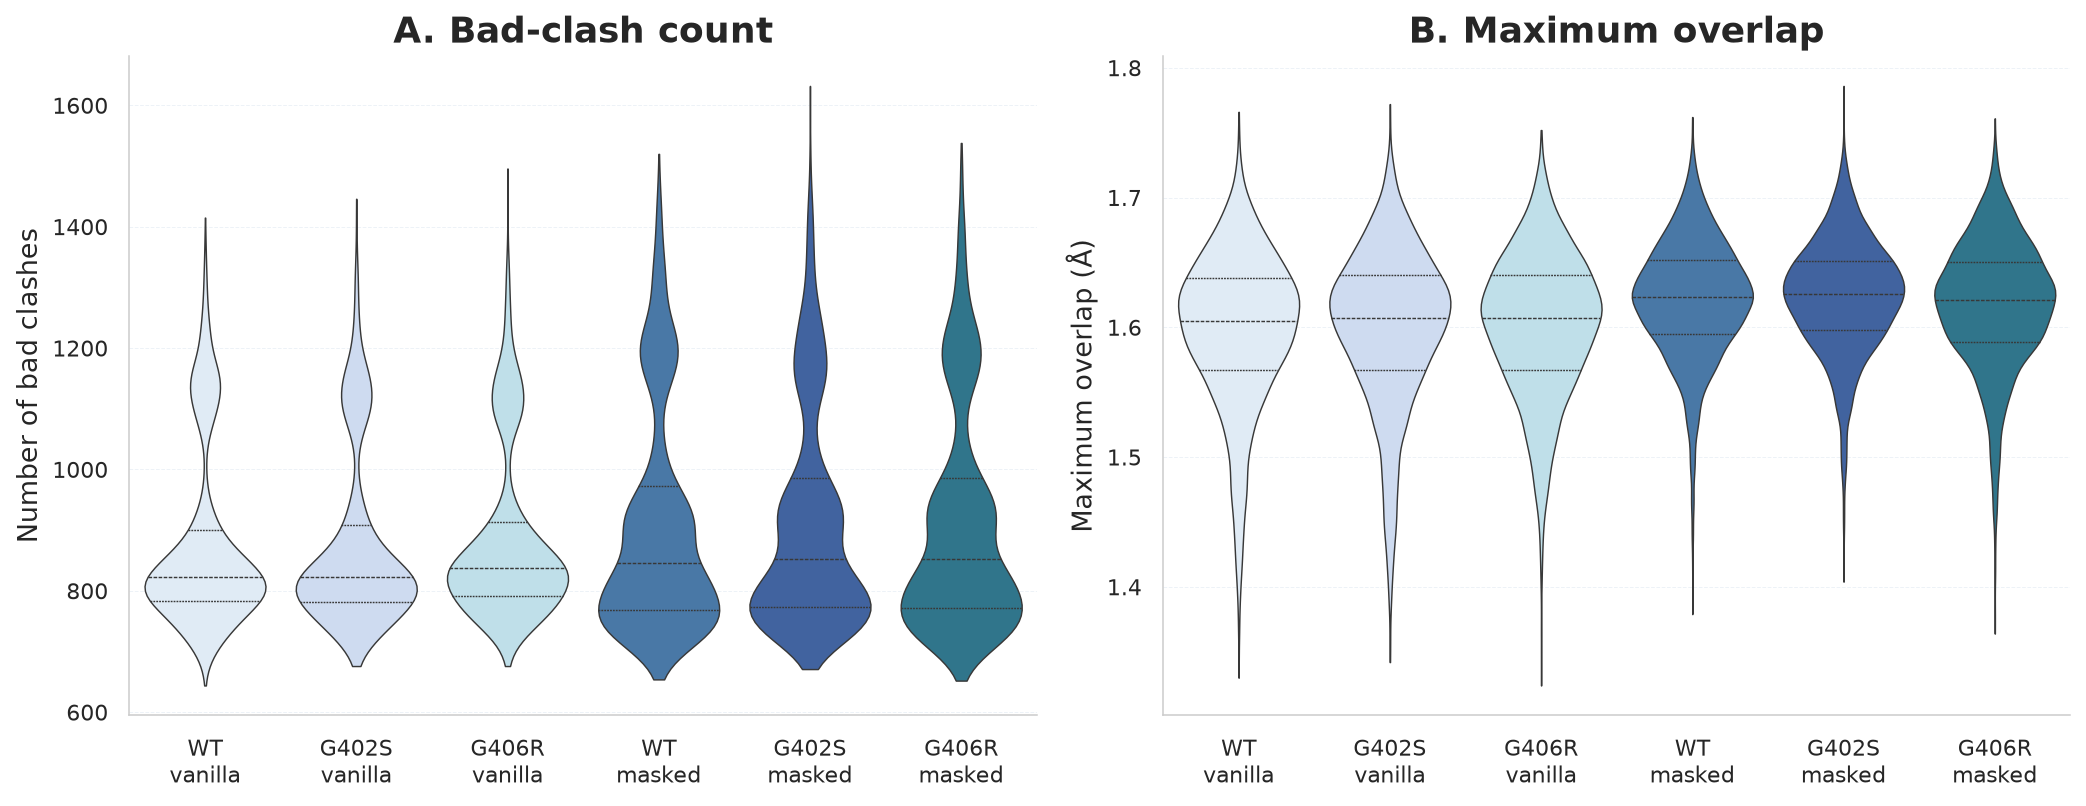

,cohort,ensemble,metric,N,n_seeds,median,Q1,Q3,IQR,mean,SD,minimum,maximum
55,repository_QC,G402S | masked,n_bad_clashes,4995,100,853.000,774.000,986.000,212.000,912.945,179.313,671.000,1632.000
56,repository_QC,G402S | masked,max_overlap,4995,100,1.626,1.598,1.651,0.053,1.623,0.044,1.404,1.786
58,repository_QC,G402S | vanilla,n_bad_clashes,5000,100,822.000,781.000,908.000,127.000,877.419,146.903,676.000,1446.000
59,repository_QC,G402S | vanilla,max_overlap,5000,100,1.607,1.567,1.640,0.073,1.599,0.062,1.342,1.772
61,repository_QC,G406R | masked,n_bad_clashes,4997,100,852.000,771.000,986.000,215.000,912.695,182.839,652.000,1538.000
62,repository_QC,G406R | masked,max_overlap,4997,100,1.621,1.589,1.650,0.061,1.617,0.050,1.364,1.761
64,repository_QC,G406R | vanilla,n_bad_clashes,5000,100,837.000,792.000,914.000,122.000,886.695,141.909,676.000,1496.000
65,repository_QC,G406R | vanilla,max_overlap,5000,100,1.607,1.567,1.640,0.073,1.601,0.056,1.324,1.752
67,repository_QC,WT | masked,n_bad_clashes,4996,100,846.000,768.000,973.000,205.000,909.541,184.259,654.000,1520.000
68,repository_QC,WT | masked,max_overlap,4996,100,1.623,1.595,1.652,0.057,1.621,0.046,1.379,1.762


,A,B,metric,median_difference,seed_mean_difference,CI_low,CI_high,seed_rank_biserial,q_BH
28,WT | vanilla,WT | masked,n_bad_clashes,23.000,30.4472,28.4680,32.3383,0.9952,0.0000
29,WT | vanilla,WT | masked,max_overlap,0.018,0.0240,0.0220,0.0260,0.9898,0.0000
31,G402S | vanilla,G402S | masked,n_bad_clashes,31.000,35.5658,33.5720,37.5763,1.0000,0.0000
32,G402S | vanilla,G402S | masked,max_overlap,0.019,0.0249,0.0227,0.0271,0.9911,0.0000
34,G406R | vanilla,G406R | masked,n_bad_clashes,15.000,26.0155,24.2807,27.7433,0.9872,0.0000
35,G406R | vanilla,G406R | masked,max_overlap,0.014,0.0159,0.0135,0.0183,0.8182,0.0000
37,WT | vanilla,G402S | vanilla,n_bad_clashes,-1.000,-1.7442,-3.8970,0.3966,-0.1056,0.1298
38,WT | vanilla,G402S | vanilla,max_overlap,0.002,0.0013,-0.0009,0.0033,0.0655,0.2718
40,WT | vanilla,G406R | vanilla,n_bad_clashes,14.000,7.5316,5.6677,9.3318,0.5432,0.0000
41,WT | vanilla,G406R | vanilla,max_overlap,0.002,0.0037,0.0015,0.0059,0.2577,0.0020


In [6]:
mp.plot_diagnostics(cohorts, CHANNEL, OUT)
plt.show()
display(summary[(summary.cohort=='repository_QC') & summary.metric.ne('clashscore')].round(3))
display(contrasts[(contrasts.cohort=='repository_QC') & contrasts.metric.ne('clashscore')][
    ['A','B','metric','median_difference','seed_mean_difference','CI_low','CI_high','seed_rank_biserial','q_BH']].round(4))


## Recycle, AF-model, seed, and rank sensitivity
The full snapshot trace includes final separately and all early-recycle tails. The final-only analysis does not substitute a last available snapshot for a missing final file. The adjusted regression controls AF-model and snapshot composition, with uncertainty clustered by seed; its observation-weighted estimand differs from the seed-balanced primary result.

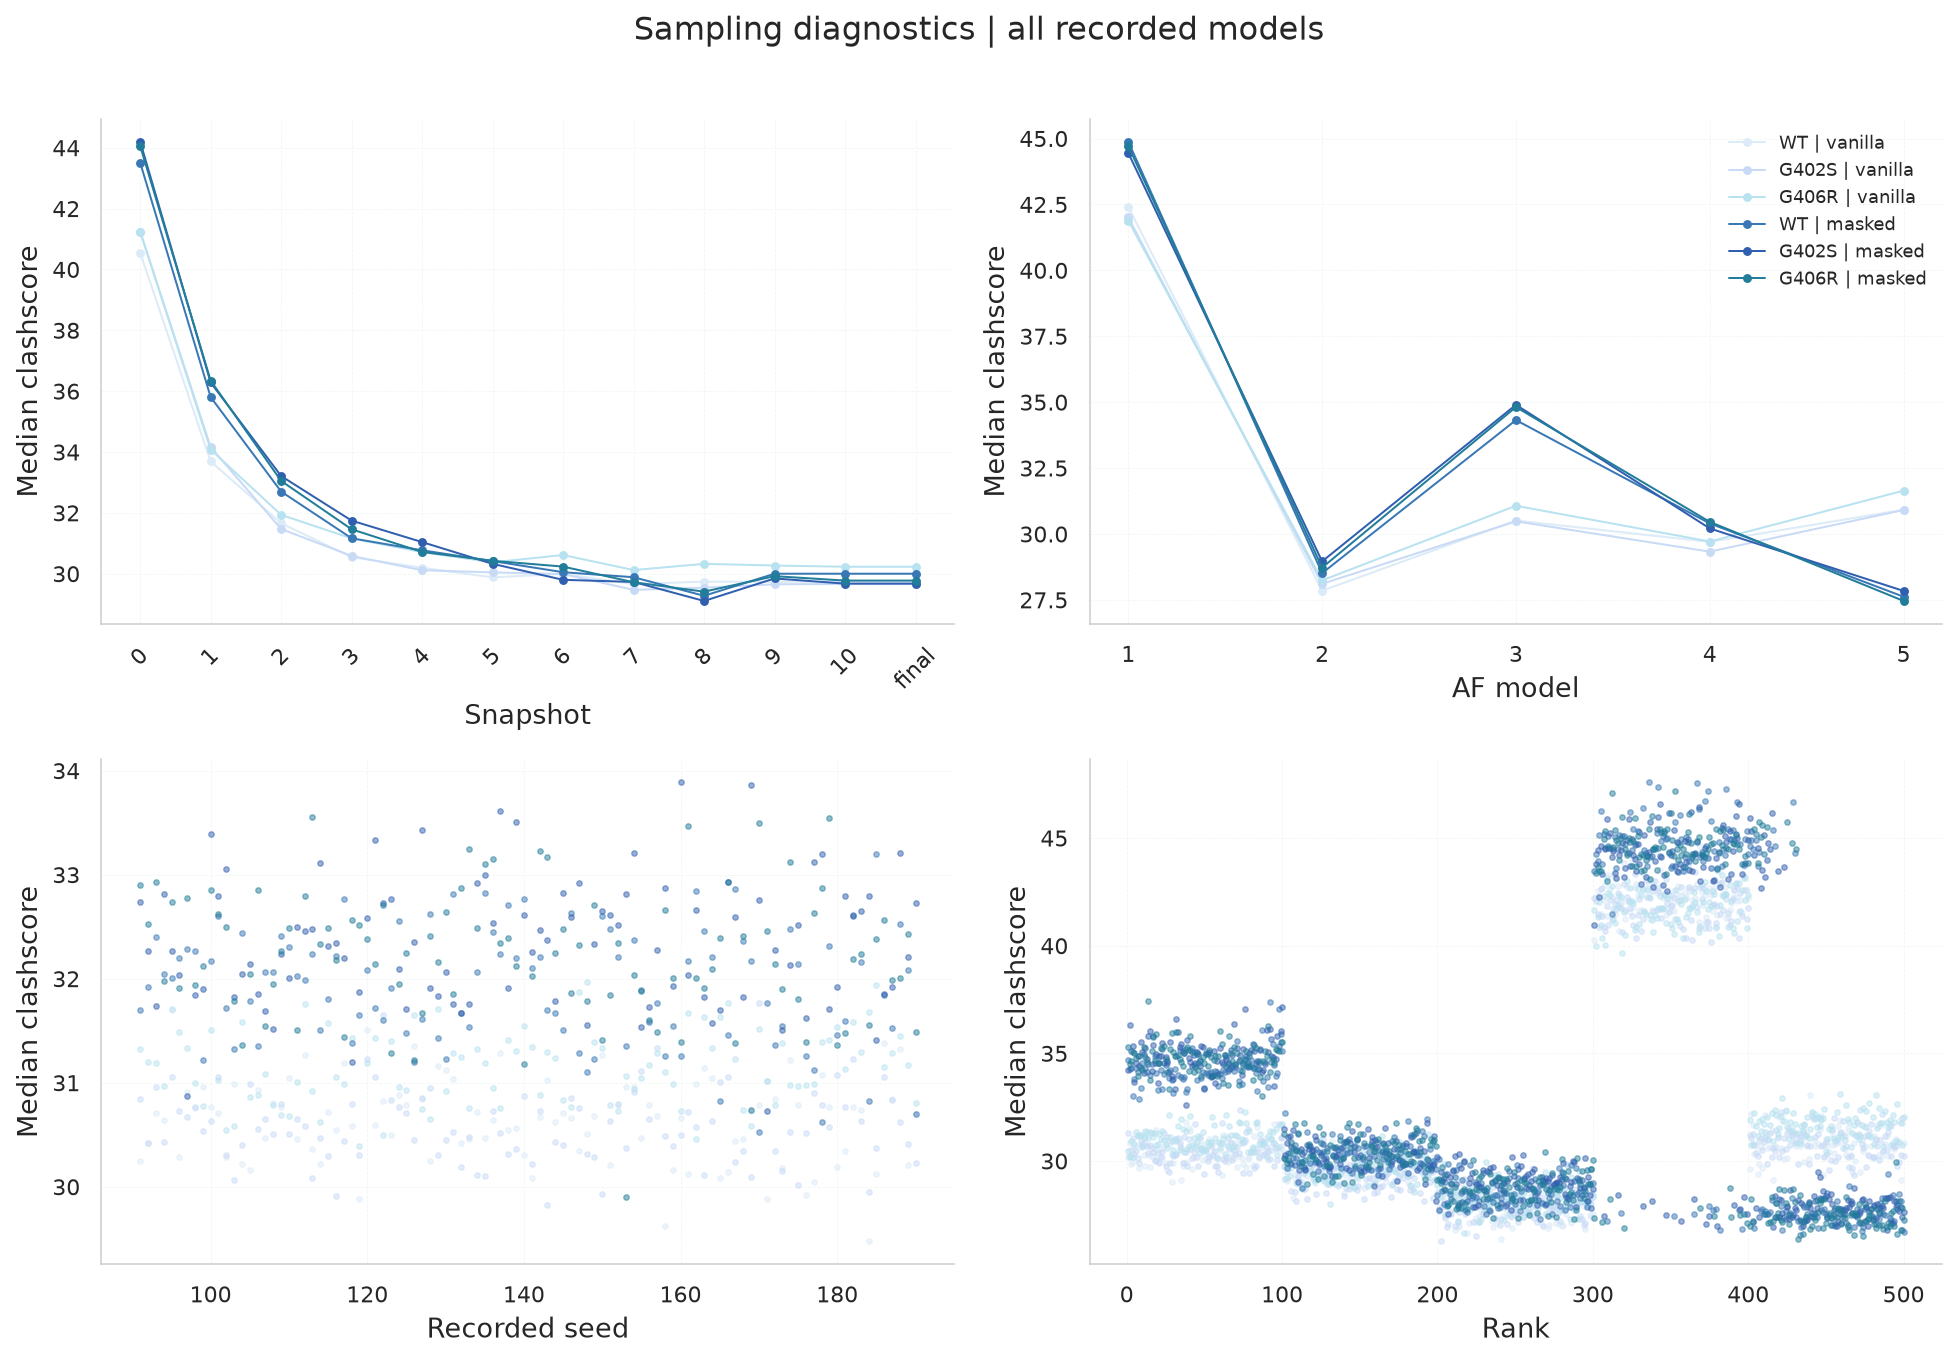

,A,B,adjusted_difference,CI_low,CI_high,p,q_BH
0,WT | vanilla,WT | masked,1.1272,1.0555,1.1988,0.0000,0.0000
1,G402S | vanilla,G402S | masked,1.3178,1.2449,1.3907,0.0000,0.0000
2,G406R | vanilla,G406R | masked,0.9645,0.8993,1.0298,0.0000,0.0000
3,WT | vanilla,G402S | vanilla,-0.0690,-0.1486,0.0105,0.0890,0.1002
4,WT | vanilla,G406R | vanilla,0.2587,0.1881,0.3293,0.0000,0.0000
5,G402S | vanilla,G406R | vanilla,0.3277,0.2521,0.4033,0.0000,0.0000
6,WT | masked,G402S | masked,0.1215,0.0427,0.2002,0.0025,0.0037
7,WT | masked,G406R | masked,0.0958,0.0065,0.1850,0.0354,0.0456
8,G402S | masked,G406R | masked,-0.0257,-0.1057,0.0543,0.5293,0.5293


AF_model                                                1      2      3  \
A               B               mode                                      
G402S | masked  G406R | masked  leave_AF_model_out -0.089  0.027 -0.020   
                                only_AF_model       0.241 -0.223 -0.036   
G402S | vanilla G402S | masked  leave_AF_model_out  0.935  1.298  0.542   
                                only_AF_model       2.826  1.372  4.397   
                G406R | vanilla leave_AF_model_out  0.428  0.363  0.268   
                                only_AF_model      -0.073  0.188  0.568   
G406R | vanilla G406R | masked  leave_AF_model_out  0.418  0.962  0.254   
                                only_AF_model       3.139  0.961  3.794   
WT | masked     G402S | masked  leave_AF_model_out  0.261  0.049  0.033   
                                only_AF_model      -0.444  0.406  0.468   
                G406R | masked  leave_AF_model_out  0.172  0.076  0.013   
                                only_AF_model      -0.203  0.183  0.432   
WT | vanilla    G402S | vanilla leave_AF_model_out  0.007 -0.149 -0.077   
                                only_AF_model      -0.372  0.250 -0.038   
                G406R | vanilla leave_AF_model_out  0.435  0.214  0.191   
                                only_AF_model      -0.445  0.438  0.529   
                WT | masked     leave_AF_model_out  0.680  1.101  0.432   
                                only_AF_model       2.897  1.216  3.891   

AF_model                                                4      5  
A               B               mode                              
G402S | masked  G406R | masked  leave_AF_model_out -0.073  0.040  
                                only_AF_model       0.177 -0.275  
G402S | vanilla G402S | masked  leave_AF_model_out  1.434  2.357  
                                only_AF_model       0.831 -2.861  
                G406R | vanilla leave_AF_model_out  0.340  0.240  
                                only_AF_model       0.279  0.677  
G406R | vanilla G406R | masked  leave_AF_model_out  1.020  2.156  
                                only_AF_model       0.729 -3.813  
WT | masked     G402S | masked  leave_AF_model_out  0.175  0.082  
                                only_AF_model      -0.100  0.272  
                G406R | masked  leave_AF_model_out  0.102  0.122  
                                only_AF_model       0.077 -0.003  
WT | vanilla    G402S | vanilla leave_AF_model_out -0.024 -0.102  
                                only_AF_model      -0.249  0.064  
                G406R | vanilla leave_AF_model_out  0.316  0.138  
                                only_AF_model       0.030  0.742  
                WT | masked     leave_AF_model_out  1.234  2.172  
                                only_AF_model       0.682 -3.069

,cohort,A,B,seed_mean_difference,CI_low,CI_high,q_BH
0,all_recycles,WT | vanilla,WT | masked,1.192,1.117,1.262,0.000
3,all_recycles,G402S | vanilla,G402S | masked,1.370,1.300,1.440,0.000
6,all_recycles,G406R | vanilla,G406R | masked,1.097,1.032,1.161,0.000
9,all_recycles,WT | vanilla,G402S | vanilla,-0.047,-0.126,0.029,0.279
12,all_recycles,WT | vanilla,G406R | vanilla,0.246,0.175,0.314,0.000
15,all_recycles,G402S | vanilla,G406R | vanilla,0.293,0.213,0.370,0.000
18,all_recycles,WT | masked,G402S | masked,0.130,0.047,0.214,0.003
21,all_recycles,WT | masked,G406R | masked,0.151,0.066,0.236,0.002
24,all_recycles,G402S | masked,G406R | masked,0.021,-0.068,0.103,0.626
27,repository_QC,WT | vanilla,WT | masked,1.124,1.051,1.194,0.000


In [7]:
mp.stratification(cohorts, CHANNEL, OUT)
plt.show()
adjusted = mp.adjusted_contrasts(cohorts, CHANNEL, OUT)
display(adjusted.round(4))
af_sensitivity = mp.af_model_sensitivity(cohorts, CHANNEL, OUT)
display(af_sensitivity.pivot(index=['A','B','mode'], columns='AF_model', values='seed_mean_difference').round(3))
display(contrasts[contrasts.metric.eq('clashscore')][
    ['cohort','A','B','seed_mean_difference','CI_low','CI_high','q_BH']].round(3))


## Focused interpretation
The following text is generated from the executed result tables so it stays synchronized with reruns.

In [8]:
display(Markdown(mp.focused_interpretation(summary, contrasts, CHANNEL, OUT)))

**G406R focus.** The global signal is small relative to within-ensemble dispersion.

- Vanilla: WT/G402S/G406R clashscore medians are 30.400/30.360/30.905; G406R−WT seed-balanced difference is +0.259 (95% CI +0.190 to +0.325). G406R−G402S is +0.328 (95% CI +0.251 to +0.402). Bad-clash medians are 823/822/837; maximum-overlap medians are 1.605/1.607/1.607 Å.

- Masked: WT/G402S/G406R clashscore medians are 31.250/31.510/31.450; G406R−WT seed-balanced difference is +0.097 (95% CI +0.010 to +0.184). G406R−G402S is -0.023 (95% CI -0.105 to +0.059). Bad-clash medians are 846/853/852; maximum-overlap medians are 1.623/1.626/1.621 Å.

The current data support modest protocol-associated global shifts, not a distinctive large G406R global clash phenotype. They cannot locate a clash at R406 or exclude a severe local contact diluted in a global score. The existing short local distances still justify parsing atom-level cluster logs: identify R406-involving atom pairs, contact frequencies and overlap magnitudes, with WT/G402S controls. Keep this global comparison as QC; local attribution remains untested.

**AF-model dependence.** The following ranges are effect magnitudes, not new hypothesis tests:

- WT masked−vanilla: individual AF-model mean differences range from -3.07 to +3.89; leaving out one AF model at a time gives +0.43 to +2.17.

- G402S masked−vanilla: individual AF-model mean differences range from -2.86 to +4.40; leaving out one AF model at a time gives +0.54 to +2.36.

- G406R masked−vanilla: individual AF-model mean differences range from -3.81 to +3.79; leaving out one AF model at a time gives +0.25 to +2.16.

Mixed signs across AF models preclude a uniform per-model masking effect. The stratified tables and final-r10 sensitivities should accompany claims based on pooled means.

## Reproducibility record
All generated outputs are confined to this channel’s `dataExtra/molprobity/{tables,figures}`. Existing figures and analyses are not overwritten. Input hashes, missing-model lists, full descriptive/contrast tables, pairing diagnostics and sensitivity results accompany the figures.

In [9]:
record = {'channel': CHANNEL, 'total_downloaded_csvs': total_csv_files,
          'channel_csvs': len(inventory), 'rows': len(raw), 'python': platform.python_version(),
          'bootstrap_replicates': mp.BOOTSTRAPS, 'random_seed': mp.RANDOM_SEED,
          'packages': {p: importlib.metadata.version(p) for p in ['numpy','pandas','scipy','statsmodels','matplotlib','seaborn']}}
(OUT/'tables/run_metadata.json').write_text(json.dumps(record, indent=2)+chr(10))
print('Completed:', OUT.relative_to(ROOT))


Completed: cav12/dataExtra/molprobity
